In [6]:
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.path as mpath
from datetime import date, timedelta
import numpy as np
import pandas as pd
import cartopy
import cartopy.crs as ccrs                   # for projections
import cartopy.feature as cfeature           # for features
import cartopy.io.shapereader as shpreader
import matplotlib.patheffects as PathEffects
from shapely.geometry import LineString, MultiLineString
import urllib.request
import os
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
from pyproj import Geod
from netCDF4 import Dataset as netcdf_dataset
import os
import cmocean

In [7]:
#Load Dataset
dataset = netcdf_dataset('barkley_sound_1_navd88_2016.nc')
depth = dataset.variables['Band1'][:, :]
lats = dataset.variables['lat'][:]
lons = dataset.variables['lon'][:]

In [8]:
import matplotlib
print(matplotlib.__version__)
print(cartopy.__version__)

3.9.2
0.24.1


<a list of 394 text.Text objects>

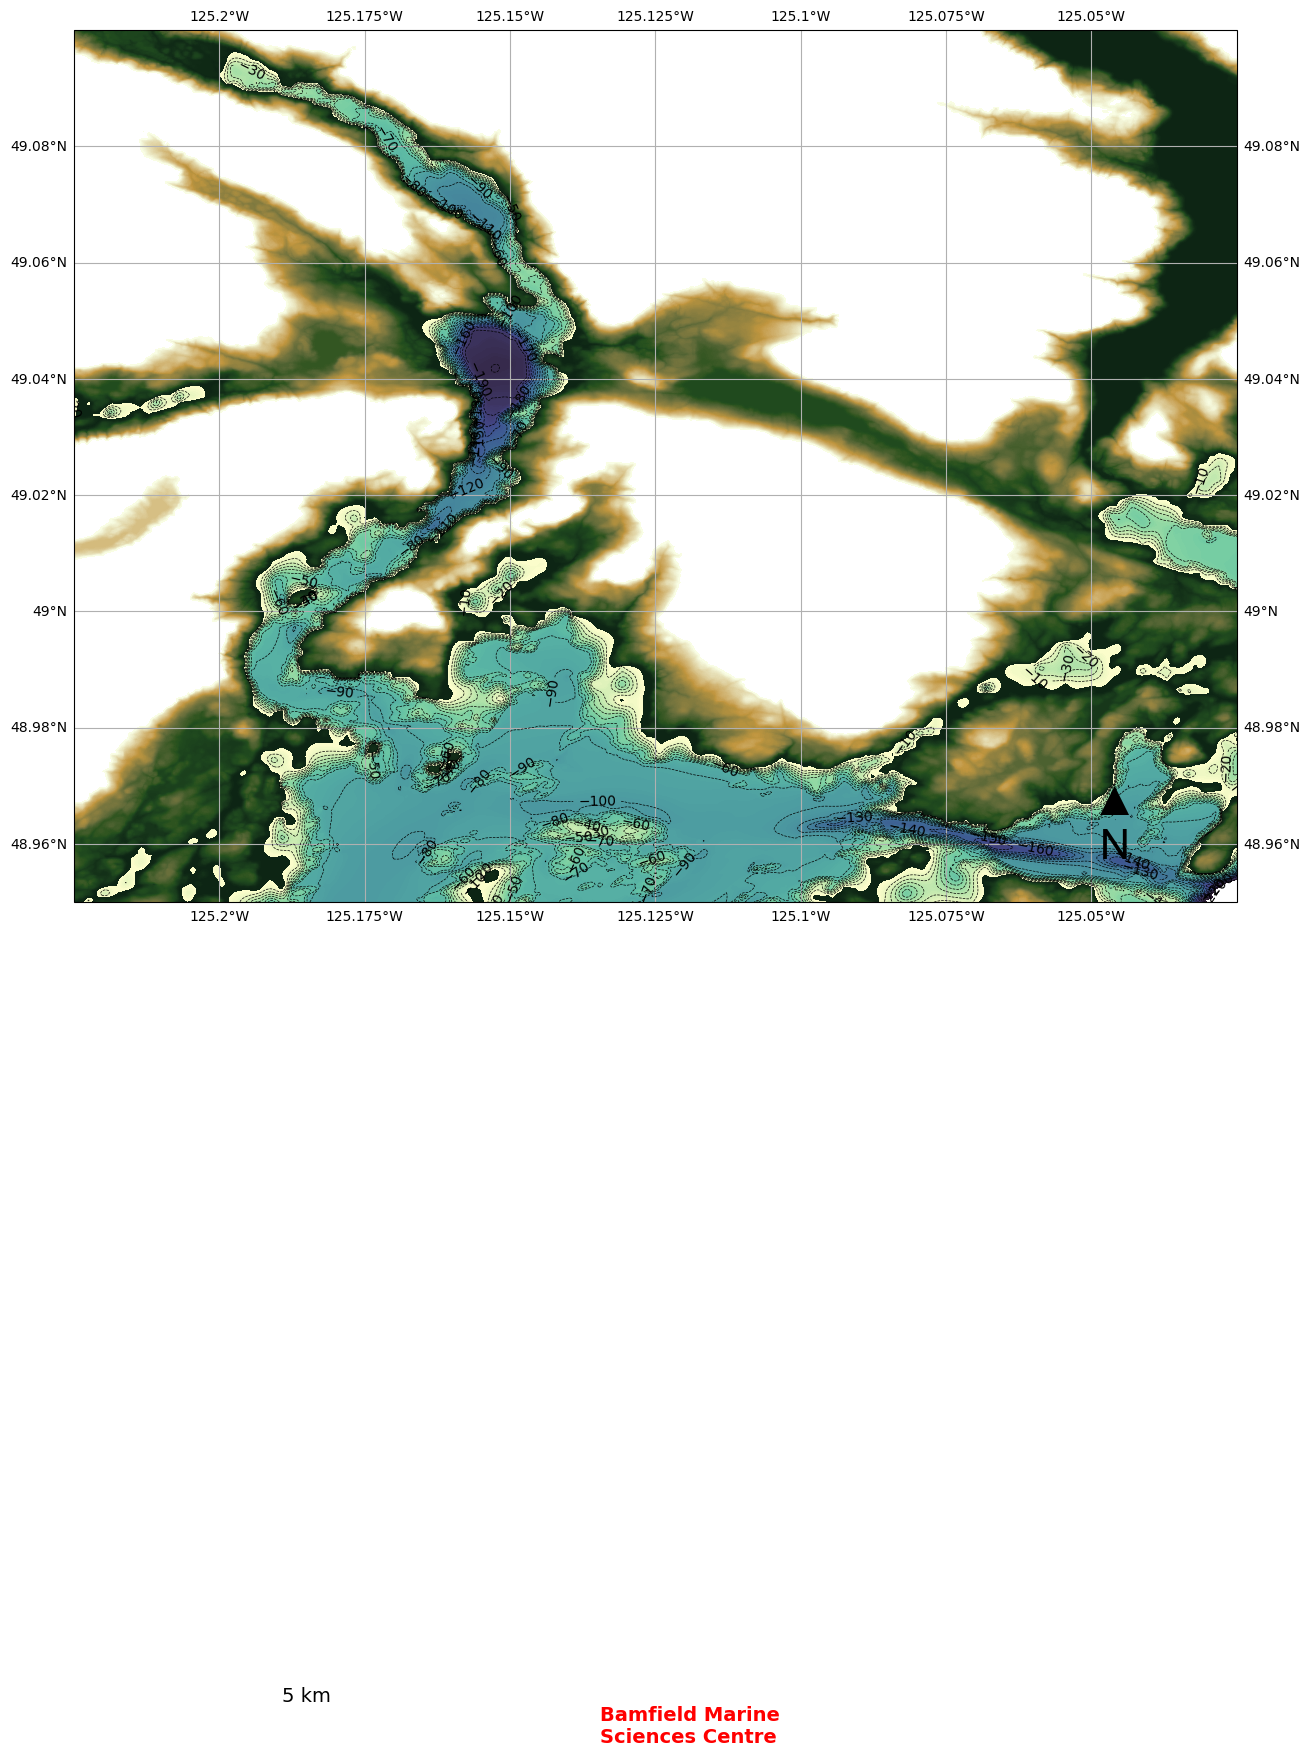

In [13]:
map_projection = ccrs.PlateCarree()

fig,ax0=plt.subplots(figsize=(15, 15),subplot_kw={'projection': map_projection})

#Create base map with high resolution coastline
# ax0.add_feature(cfeature.GSHHSFeature(scale='full',levels=[1]),zorder=2)
# ax0.set_extent([-125.225,-125.025,48.8,48.925])
ax0.set_extent([-125.225,-125.025,48.95,49.1])
#ax0.set_facecolor('lightblue')


#Set ticks
# ax0.set_xticks([105,106,107,108,109,110,111,112,113], crs=ccrs.PlateCarree())
# ax0.set_yticks([15,16,17,18,19,20,21,22], crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax0.xaxis.set_major_formatter(lon_formatter)
ax0.yaxis.set_major_formatter(lat_formatter)
ax0.gridlines(draw_labels=True)


#Plot cities with markers
BMSC_lat=48.8355
BMSC_long=-125.1355
ax0.scatter(BMSC_long,BMSC_lat,s=120,color='k',transform=ccrs.PlateCarree(),zorder=2)
ax0.scatter(BMSC_long,BMSC_lat,s=90,color='white',transform=ccrs.PlateCarree(),zorder=2)
ax0.scatter(BMSC_long,BMSC_lat,s=60,color='k',transform=ccrs.PlateCarree(),zorder=2)
ax0.text(BMSC_long+0.001,BMSC_lat-0.03,'Bamfield Marine' '\n' 'Sciences Centre',fontweight='bold',c='red',fontsize=14,transform=ccrs.PlateCarree())


#North Arrow
ax0.text(0.9, 0.05,u'\u25B2 \nN ', ha='center', fontsize=30, family='Arial',transform=ax0.transAxes)

#Scale bar
lon = -125.22
lat  = 48.81
geod = Geod(ellps="WGS84")
lon_end1, lat_end1, azi_rev1 = geod.fwd(lon, lat, 90, 5000)
ax0.plot([lon_end1, lon], [lat_end1, lat], "k-",transform=ccrs.Geodetic())
ax0.plot([lon,lon],[lat,lat+0.002],'k')
ax0.plot([lon_end1,lon_end1],[lat,lat+0.002],'k')
ax0.text(x=lon+0.035,y=lat+0.0025,s='5 km',fontsize=14,ha='center',transform=ccrs.PlateCarree())

dataset = netcdf_dataset('barkley_sound_1_navd88_2016.nc')
depth = dataset.variables['Band1'][:, :]
lats = dataset.variables['lat'][:]
lons = dataset.variables['lon'][:]


CS1=ax0.contourf(lons, lats, depth, levels = np.linspace(-220,220,441), cmap=cmocean.cm.topo,transform=ccrs.PlateCarree(),zorder=1)
CS2=ax0.contour(lons, lats, depth, levels = np.linspace(-220,-10,22), colors = 'black',linewidths=0.5, transform=ccrs.PlateCarree(),zorder=2)
ax0.clabel(CS2,CS2.levels)

# ax0.plot(-125.11145,48.87414,'*',color='red',markersize=30,markeredgecolor='k',transform=ccrs.PlateCarree())
# ax0.plot(-125.11520,48.85593,'*',color='purple',markersize=30,markeredgecolor='k',transform=ccrs.PlateCarree())

# #Inset plotting
# axins = inset_axes(ax0, width="25%", height="25%", loc="upper left", 
#                    axes_class=cartopy.mpl.geoaxes.GeoAxes, 
#                    axes_kwargs=dict(projection=cartopy.crs.PlateCarree()))
# axins.add_feature(cfeature.GSHHSFeature(scale='full',levels=[1]))
# axins.add_feature(cfeature.LAND,color='lightgrey')
# # axins.add_feature(cfeature.BORDERS)
# # sub region of the original image
# axins.set_xlim([-126,-124])
# axins.set_ylim([48,50])
# axins.add_patch(Rectangle((-125.3, 48.7), 0.25, 0.25, edgecolor = 'red', fill=False,lw=2))

# lon_formatter_ins = LongitudeFormatter(zero_direction_label=False)
# lat_formatter_ins = LatitudeFormatter()
# axins.xaxis.set_major_formatter(lon_formatter_ins)
# axins.yaxis.set_major_formatter(lat_formatter_ins)
# axins.set_xticks([-126,-125,-124], crs=ccrs.PlateCarree())
# axins.set_yticks([48,49,50], crs=ccrs.PlateCarree())
# axins.yaxis.tick_right()



# ax0.set_xticklabels(ax0.get_xticks(), fontsize=24)
# ax0.set_yticklabels(ax0.get_yticks(), fontsize=24)

In [ ]:
map_projection = ccrs.PlateCarree()

fig,ax0=plt.subplots(figsize=(12, 12),subplot_kw={'projection': map_projection})


#Create base map with high resolution coastline
# ax0.add_feature(cfeature.GSHHSFeature(scale='full',levels=[1]),zorder=2)
ax0.set_extent([-125.175,-125.1,48.82,48.88])
#ax0.set_facecolor('lightblue')


#Set ticks
# ax0.set_xticks([105,106,107,108,109,110,111,112,113], crs=ccrs.PlateCarree())
# ax0.set_yticks([15,16,17,18,19,20,21,22], crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax0.xaxis.set_major_formatter(lon_formatter)
ax0.yaxis.set_major_formatter(lat_formatter)
ax0.gridlines(draw_labels=True)

#Plot cities with markers
BMSC_lat=48.8355
BMSC_long=-125.1355
ax0.scatter(BMSC_long,BMSC_lat,s=140,color='k',transform=ccrs.PlateCarree(),zorder=2)
ax0.scatter(BMSC_long,BMSC_lat,s=90,color='white',transform=ccrs.PlateCarree(),zorder=2)
ax0.scatter(BMSC_long,BMSC_lat,s=40,color='k',transform=ccrs.PlateCarree(),zorder=2)
ax0.text(BMSC_long-0.001,BMSC_lat-0.0025,'BMSC',c='white',fontsize=24,transform=ccrs.PlateCarree())


#North Arrow
ax0.text(0.9, 0.05,u'\u25B2 \nN ', ha='center', color='white', fontsize=30, family='Arial',transform=ax0.transAxes)

# #Scale bar
# lon = -125.22
# lat  = 48.81
# geod = Geod(ellps="WGS84")
# lon_end1, lat_end1, azi_rev1 = geod.fwd(lon, lat, 90, 5000)
# ax0.plot([lon_end1, lon], [lat_end1, lat], "k-",transform=ccrs.Geodetic())
# ax0.plot([lon,lon],[lat,lat+0.002],'k')
# ax0.plot([lon_end1,lon_end1],[lat,lat+0.002],'k')
# ax0.text(x=lon+0.035,y=lat+0.0025,s='5 km',fontsize=14,ha='center',transform=ccrs.PlateCarree())

CS1=ax0.contourf(lons, lats, depth, levels = np.linspace(-220,220,441), cmap=cmocean.cm.topo,transform=ccrs.PlateCarree(),zorder=1)
CS2=ax0.contour(lons, lats, depth, levels = np.linspace(-220,0,23), colors = 'black', transform=ccrs.PlateCarree(),zorder=2)
ax0.clabel(CS2,CS2.levels)

# #Inset plotting
# axins = inset_axes(ax0, width="25%", height="25%", loc="upper left", 
#                    axes_class=cartopy.mpl.geoaxes.GeoAxes, 
#                    axes_kwargs=dict(projection=cartopy.crs.PlateCarree()))
# axins.add_feature(cfeature.GSHHSFeature(scale='full',levels=[1]))
# axins.add_feature(cfeature.LAND,color='lightgrey')
# # axins.add_feature(cfeature.BORDERS)
# # sub region of the original image
# axins.set_xlim([-126,-124])
# axins.set_ylim([48,50])
# axins.add_patch(Rectangle((-125.3, 48.7), 0.25, 0.25, edgecolor = 'red', fill=False,lw=2))


# lon_formatter_ins = LongitudeFormatter(zero_direction_label=False)
# lat_formatter_ins = LatitudeFormatter()
# axins.xaxis.set_major_formatter(lon_formatter_ins)
# axins.yaxis.set_major_formatter(lat_formatter_ins)
# axins.set_xticks([-126,-125,-124], crs=ccrs.PlateCarree())
# axins.set_yticks([48,49,50], crs=ccrs.PlateCarree())
# axins.yaxis.tick_right()

In [9]:
display(dataset.variables)

{'crs': <class 'netCDF4.Variable'>
 |S1 crs()
     grid_mapping_name: latitude_longitude
     long_name: CRS definition
     longitude_of_prime_meridian: 0.0
     semi_major_axis: 6378137.0
     inverse_flattening: 298.257223563
     spatial_ref: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]]
     GeoTransform: -125.57013888889 0.0002777777799999974 0 49.10986111439 0 -0.0002777777799999974 
 unlimited dimensions: 
 current shape = ()
 filling on, default _FillValue of   used,
 'lat': <class 'netCDF4.Variable'>
 float64 lat(lat)
     standard_name: latitude
     long_name: latitude
     units: degrees_north
     actual_range: [48.69986111 49.10986111]
 unlimited dimensions: 
 current shape = (1476,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'lon': <class 'netCDF4.Variable'>
 float64 lon(lon)
     standard_n